# Build LogD GAT model.

This notebook shows how to build an attention-based model (GATv2Conv) to train, predict and evaluate LogD from Chembl data. 

In [ ]:
import itertools
import os
import pathlib
from pathlib import Path

from multiprocessing import Pool

import pandas as pd
import numpy as np

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, Descriptors3D, rdMolDescriptors, rdPartialCharges
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

import torch
import torch.nn.functional as F
import torch.nn as nn

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool
from torch_geometric.data import Batch

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Setup.

In [2]:
readout = 'LogD7.4'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [4]:
# Load chembl data

df = pd.read_csv(f'{DATA}/{readout}_chembl.csv',index_col=None)
len(df)

7713

In [5]:
smiles_list = df['smiles'].tolist()
logd_values = df['standard_value'].tolist()

Pytorch geometric fix

In [6]:
# Here we define our own data structure for Pytorch Geometric to use in the model.
# Why? In the functions below, PyG's Batch.from_data_list tries to automatically 
# concatenate all descriptors and layers and gets the feature vector size wrong unless instructed not to. 
# (1D vector of 288 instead of 2D vector odf 32 x 9 chemical features)  
# global_features should be stacked (batched), not concatenated - the __cat_dim__ method controls that.

from torch_geometric.data import Data

class MoleculeData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        return super().__inc__(key, value)

    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == 'global_features':
            return None  # do not concatenate along any dimension
        return super().__cat_dim__(key, value)


## Featurisation step.

### Add Morgan fps and 3D descriptors as global predictors

In [7]:
def get_morgan_fingerprint(mol, radius=2, nBits=1024):
    generator = GetMorganGenerator(radius=radius, fpSize=nBits)
    fp = generator.GetFingerprint(mol)
    arr = np.zeros((nBits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr.astype(np.float32)


In [43]:
def get_3d_descriptors(mol):
    mol = Chem.AddHs(mol)

    try:
        if AllChem.EmbedMolecule(mol, AllChem.ETKDG()) != 0:
            return np.zeros(6, dtype=np.float32)

        # Check for UFF optimization support
        try:
            AllChem.UFFOptimizeMolecule(mol)
        except:
            return np.zeros(6, dtype=np.float32)

        descs = [
            Descriptors3D.Asphericity(mol),
            Descriptors3D.Eccentricity(mol),
            Descriptors3D.InertialShapeFactor(mol),
            Descriptors3D.SpherocityIndex(mol),
            rdMolDescriptors.CalcVolume(mol),
            rdMolDescriptors.CalcLabuteASA(mol)
        ]

        descs = [0.0 if np.isnan(d) or np.isinf(d) else d for d in descs]
        return np.array(descs, dtype=np.float32)

    except Exception as e:
        return np.zeros(6, dtype=np.float32)


In [44]:
# We can get reasonable results (R^2 ~ 0.5) with simple atomic features.
# But as we are trying to predict a more complex phenomena, we can benefit from RdKit 
# descriptors to encode hybridisation, partial charges, etc.
# LogD prediction should improve from here.

from rdkit.Chem import rdPartialCharges, rdMolDescriptors, Descriptors, PeriodicTable

descriptor_functions = [
    Descriptors.MolWt,
    Descriptors.MolLogP,
    Descriptors.NumHDonors,
    Descriptors.NumHAcceptors,
    Descriptors.TPSA,
    Descriptors.FractionCSP3,
    Descriptors.HeavyAtomCount,
    Descriptors.NumRotatableBonds,
    Descriptors.RingCount
]

# Precompute a dict of electronegativities (Pauling scale)
electronegativity_dict = {
    1: 2.20, 6: 2.55, 7: 3.04, 8: 3.44, 9: 3.98, 15: 2.19,
    16: 2.58, 17: 3.16, 35: 2.96, 53: 2.66,
}

# List of metals by atomic number (common metals)
metals = {
    3, 4, 11, 12, 13, 19, 20, 21, 22, 23, 24, 25,
    26, 27, 28, 29, 30, 37, 38, 39, 40, 41, 42,
    43, 44, 45, 46, 47, 48, 49, 55, 56, 57, 72,
    73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
    87, 88, 89, 104, 105, 106, 107, 108, 109, 110,
    111, 112, 113, 114, 115, 116
}

def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]  # fallback to "unknown"
    return [int(x == s) for s in allowable_set]

def get_atom_features(atom, mol=None):
    pt = Chem.GetPeriodicTable()
    features = []

    # Atom symbol (one-hot + unknown)
    features += one_hot_encoding(atom.GetSymbol(),
                                ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'H',
                                 'B', 'Si', 'Se', 'As', 'Al', 'Zn', 'Cu', 'Ni', 'Fe', 'other'])

    # Hybridization (one-hot)
    features += one_hot_encoding(atom.GetHybridization(),
                                [Chem.rdchem.HybridizationType.SP,
                                 Chem.rdchem.HybridizationType.SP2,
                                 Chem.rdchem.HybridizationType.SP3,
                                 Chem.rdchem.HybridizationType.SP3D,
                                 Chem.rdchem.HybridizationType.SP3D2,
                                 Chem.rdchem.HybridizationType.UNSPECIFIED])

    # Integer-valued features (can be scaled later if needed)
    features += [
        atom.GetDegree(),               # n_bonded neighbors
        atom.GetFormalCharge(),
        atom.GetNumRadicalElectrons(),
        int(atom.GetIsAromatic())
    ]

    atomic_num = atom.GetAtomicNum()

    # Physical properties from periodic table (normalised to 0-1)
    # We could prpbably play with this, if we want to.
    features += [
        pt.GetAtomicWeight(atomic_num) / 200,                 # ~1–200 → 0–1
        pt.GetRvdw(atomic_num) / 2.5,                         # ~0.5–2.5 → 0–1
        electronegativity_dict.get(atomic_num, 0.0) / 4.0,    # ~0–4 → 0–1
        pt.GetNOuterElecs(atomic_num) / 8.0,                  # Valence electrons, ~0–8
        1.0 if atomic_num in metals else 0.0                  # binary
    ]


    # Partial charge (Gasteiger)
    # Something else we could play with (e.g. AM1-BCC) but this adds cost.
    if mol is not None:
        try:
            charge = float(atom.GetProp('_GasteigerCharge'))
            if np.isnan(charge) or np.isinf(charge):
                charge = 0.0
        except:
            charge = 0.0
        features += [charge]
    else:
        features += [0.0]

    return np.array(features, dtype=np.float32)

def get_bond_features(bond):
    bond_type = bond.GetBondType()
    features = [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ]
    return np.array(features, dtype=np.float32)


## Convert Featurised molecules into graph for the model.

In [45]:
def mol_to_graph(smiles: str, label: float = None, radius=2, nBits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except:
        pass

    atom_features = [get_atom_features(atom, mol) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_feat = get_bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr += [bond_feat, bond_feat]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Global features
    global_features = []

    # RDKit descriptors
    for func in descriptor_functions:
        try:
            val = func(mol)
            if np.isnan(val) or np.isinf(val):
                val = 0.0
        except:
            val = 0.0
        global_features.append(val)

    # Add Morgan fingerprint
    fp = get_morgan_fingerprint(mol, radius=radius, nBits=nBits)
    global_features += fp.tolist()

    # Add 3D descriptors
    desc3d = get_3d_descriptors(mol)
    global_features += desc3d.tolist()

    global_features = torch.tensor(global_features, dtype=torch.float32)

    data = MoleculeData(x=x, edge_index=edge_index, edge_attr=edge_attr, global_features=global_features)

    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)

    return data

Data loader code.

In [46]:
# We have to tell the DataLoader which features to expect.

def compute_global_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # fallback vector of zeros if mol fails
        return torch.zeros(len(descriptor_functions), dtype=torch.float)
    feats = [fn(mol) for fn in descriptor_functions]
    return torch.tensor(feats, dtype=torch.float)

In [47]:
def _collate(batch_list):
    return Batch.from_data_list(batch_list)

In [48]:
# function to adjust number of cpus for calculation below, leaving some free for other work

total_cpus = os.cpu_count()
reserve_cpus = 4  # make sure we leave this many CPUs free
num_workers = max(1, total_cpus - reserve_cpus)

print(f"Using {num_workers} out of {total_cpus} available CPU cores.")

def process_mol(args):
    smi, lbl = args
    data = mol_to_graph(smi, lbl)
    return data

with Pool(processes=num_workers) as pool:
    results = pool.map(process_mol, zip(smiles_list, logd_values))

data_list = [data for data in results if data is not None]

# from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=16, shuffle=True, collate_fn=_collate)

Using 16 out of 20 available CPU cores.


/tmp/ipykernel_13518/2024738634.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor(atom_features, dtype=torch.float)
/tmp/ipykernel_13518/2024738634.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor(atom_features, dtype=torch.float)
/tmp/ipykernel_13518/2024738634.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor

## The Regression model definition.

In [ ]:
# Use GATv2Conv as the attention should more effectively capture functional groups.

class GATv2Regressor(torch.nn.Module):
    def __init__(self, input_dim, edge_dim, hidden_dim=128, heads=2, global_feat_dim=0):
        super().__init__()

        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        self.gat1 = GATv2Conv(input_dim, hidden_dim, heads=heads, dropout=0.1, edge_dim=hidden_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=0.1, edge_dim=hidden_dim)

        # MLP to compress global features
        self.global_mlp = nn.Sequential(
            nn.Linear(global_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )

        # Final regressor head (combined GNN + global)
        self.lin = nn.Sequential(
            nn.Linear(hidden_dim + (hidden_dim // 2), hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        device = next(self.parameters()).device

        x, edge_index, edge_attr, batch = x.to(device), edge_index.to(device), edge_attr.to(device), batch.to(device)
        edge_attr = self.edge_encoder(edge_attr)

        x = self.gat1(x, edge_index, edge_attr)
        x = F.elu(x)
        x = self.gat2(x, edge_index, edge_attr)
        x = F.elu(x)

        x = global_mean_pool(x, batch)  # GNN output: [batch_size, hidden_dim]

        if hasattr(data, 'global_features'):
            global_features = data.global_features.to(x.device)  # [batch_size, global_feat_dim]
            g_feat = self.global_mlp(global_features)            # [batch_size, hidden_dim // 2]
            x = torch.cat([x, g_feat], dim=1)                    # Concatenate

        return self.lin(x).squeeze(1)

## Training loop.

With train / val split, early stopping and grid search.

In [50]:
train_list, val_list = train_test_split(data_list, test_size=0.2, random_state=42)

train_loader = DataLoader(train_list, batch_size=32, shuffle=True, collate_fn=_collate)
val_loader = DataLoader(val_list, batch_size=32, shuffle=False, collate_fn=_collate)

In [51]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.to(device).float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            total_loss += loss.item()
            all_preds.append(out.cpu())
            all_labels.append(batch.y.cpu())
    return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

In [52]:
def train_with_early_stopping(params):
    model = GATv2Regressor(
        input_dim=params['input_dim'],
        edge_dim=params['edge_dim'],
        hidden_dim=params['hidden_dim'],
        heads=2,
        global_feat_dim=params.get('global_feat_dim', 0)
    )
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0

    for epoch in range(100):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, _, _ = eval_epoch(model, val_loader, loss_fn, device)
        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if not torch.isnan(torch.tensor(val_loss)) and val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(torch.load('best_model.pth'))
    return model

With hyperparameter tuning.

In [56]:
# param_grid = {
#     'lr': [0.001],
#     'hidden_dim': [64, 128],
# }

# Larger grid search helps

param_grid = {
    'lr': [1e-4, 5e-4, 1e-3],
    'hidden_dim': [64, 128, 256],
    'dropout': [0.0, 0.1, 0.2],
    'batch_size': [16, 32, 64]
}

global_feat_dim = len(descriptor_functions) + 1024 + 6  # RDKit + ECFP + 3D

input_dim = data_list[0].x.shape[1]
edge_dim = data_list[0].edge_attr.shape[1]

best_model = None
best_val_loss = float('inf')
best_params = None

for lr, hidden_dim in itertools.product(param_grid['lr'], param_grid['hidden_dim']):
    print(f"Training with lr={lr}, hidden_dim={hidden_dim}")
    params = {
        'lr': lr,
        'hidden_dim': hidden_dim,
        'input_dim': input_dim,
        'edge_dim': edge_dim,
        'global_feat_dim': global_feat_dim
    }
    model = train_with_early_stopping(params)
    val_loss, _, _ = eval_epoch(model, val_loader, torch.nn.MSELoss(), device)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        best_params = params

print(f"Best params: {best_params}")


Training with lr=0.0001, hidden_dim=64
Epoch 1 | Train Loss: 3.1998 | Val Loss: 2.7543
Epoch 2 | Train Loss: 1.9749 | Val Loss: 1.9308
Epoch 3 | Train Loss: 1.6165 | Val Loss: 1.6170
Epoch 4 | Train Loss: 1.4841 | Val Loss: 1.5040
Epoch 5 | Train Loss: 1.3975 | Val Loss: 1.4184
Epoch 6 | Train Loss: 1.3242 | Val Loss: 1.3428
Epoch 7 | Train Loss: 1.2377 | Val Loss: 1.2633
Epoch 8 | Train Loss: 1.1581 | Val Loss: 1.1907
Epoch 9 | Train Loss: 1.0818 | Val Loss: 1.1817
Epoch 10 | Train Loss: 1.0253 | Val Loss: 1.0975
Epoch 11 | Train Loss: 0.9700 | Val Loss: 1.0716
Epoch 12 | Train Loss: 0.9292 | Val Loss: 0.9876
Epoch 13 | Train Loss: 0.8926 | Val Loss: 0.9742
Epoch 14 | Train Loss: 0.8519 | Val Loss: 0.9362
Epoch 15 | Train Loss: 0.8292 | Val Loss: 0.9192
Epoch 16 | Train Loss: 0.7976 | Val Loss: 0.8898
Epoch 17 | Train Loss: 0.7824 | Val Loss: 0.9284
Epoch 18 | Train Loss: 0.7576 | Val Loss: 0.8628
Epoch 19 | Train Loss: 0.7447 | Val Loss: 0.8762
Epoch 20 | Train Loss: 0.7389 | Val Los

## Evaluation


RMSE: 0.7615
MAE: 0.5425
R²: 0.7450


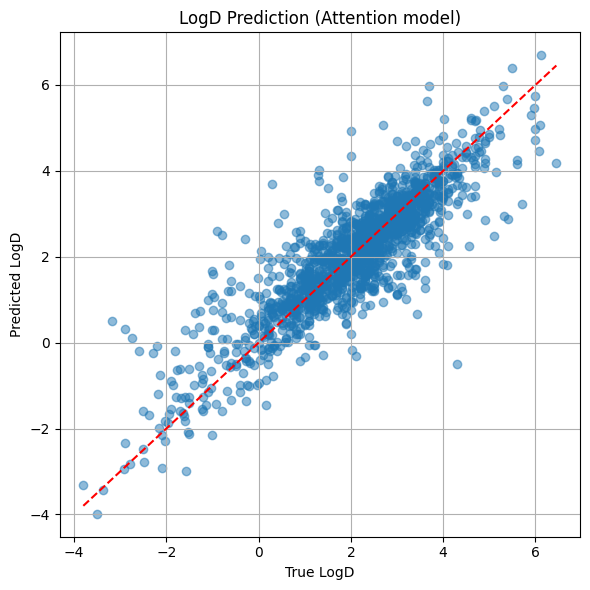

In [57]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = model(batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nRMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# Plot true vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True LogD")
plt.ylabel("Predicted LogD")
plt.title("LogD Prediction (Attention model)")
plt.grid(True)
plt.tight_layout()
plt.savefig("logd_pred_vs_true.png", dpi=300)
plt.show()


R^2 of ~0.75 is actually pretty reasonable.

To improve the model, we could try:

* Check the results against a simpler model - maybe we don't need such a heavy workflow?
* Normalise global features.
* Add more informative (3D) Rdkit descriptors (e.g. SASA, SLogP)
* Use pretrained embeddings from validated models.
* Use a different graph readout (global_add_pool instead of global_mean_pool)
* Add tautomers.
* Generated multiple conformers and average predictions.
* Tune the model (more attention heads, larger models, deeper stacks 3-4 GATv2 layers, etc.)
* Play with x-validation as maybe R^2 isn't the best metric.
* For now, we will keep the model and use it, although we could definitely work to improve it

In [55]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "edge_dim": edge_dim,
    "hidden_dim": hidden_dim,
    "global_feat_dim": global_feat_dim
    }, "logd_gat.pt")